# Lesson 17 - Capstone: Hidden Experts Discovery

**Objective**: Identify hidden organizational experts using multi-metric centrality scoring
**Duration**: 120 minutes
**Prerequisites**: Lessons 0-5 (foundational), optionally 9-11

## Scenario
Your organization has 18 support staff across 5 teams handling 150+ issues monthly.
Goal: Identify hidden expertise, find bottlenecks, and prevent burnout of key people.

Tasks:
1. Who are the real experts? (Not just high-degree nodes)
2. What types of expertise exist? (Bottlenecks, bridges, influencers, siloed)
3. Who's at risk of burnout? (Overloaded + invisible influence)
4. How to redesign escalation paths? (Reduce single points of failure)
5. What knowledge is hidden? (Underutilized expertise)


In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/home/marek/Apps/graph-analysis-course')
from src.utils.io import read_csv
from src.utils.random_seed import set_random_seed
from src.config import Config

set_random_seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('[OK] Imports successful')
print(f'[OK] Working directory: {Config.PROJECT_ROOT}')


[OK] Imports successful
[OK] Working directory: /home/marek/Apps/graph-analysis-course


In [2]:
# Cell 2: Load Data
data_dir = Config.DATA_SEED_DIR / 'hidden_experts'

teams_df = read_csv(data_dir / 'teams.csv')
people_df = read_csv(data_dir / 'people.csv')
issues_df = read_csv(data_dir / 'issues.csv')
escalations_df = read_csv(data_dir / 'escalations.csv')

print('[OK] Data loaded')
print(f'  Teams: {len(teams_df)}')
print(f'  People: {len(people_df)}')
print(f'  Issues: {len(issues_df)}')
print(f'  Escalations: {len(escalations_df)}')

print('\n[DATA] People (first 3):')
print(people_df.head(3))
print('\n[DATA] Escalations (first 3):')
print(escalations_df.head(3))
print('\n[DATA] Issues (first 3):')
print(issues_df.head(3))


[OK] Data loaded
  Teams: 5
  People: 18
  Issues: 150
  Escalations: 180

[DATA] People (first 3):
   person_id             name                     email  team_id  \
0  PERSON_00     Allison Hill  donaldgarcia@example.net  TEAM_04   
1  PERSON_01  Angie Henderson    davisjesse@example.net  TEAM_04   
2  PERSON_02  Cristian Santos     lrobinson@example.com  TEAM_01   

            title  seniority  is_manager  
0  Senior Support          2       False  
1  Junior Support          1       False  
2  Senior Support          2       False  

[DATA] Escalations (first 3):
  from_person_id to_person_id  escalation_count
0      PERSON_01    PERSON_00                 7
1      PERSON_02    PERSON_00                 4
2      PERSON_03    PERSON_00                 5

[DATA] Issues (first 3):
     issue_id                             title  \
0  ISSUE_0000     Sharable bifurcated algorithm   
1  ISSUE_0001         Reactive explicit product   
2  ISSUE_0002  Cloned well-modulated monitoring   

 

In [3]:
# Cell 3: Build Graph
G_escalation = nx.DiGraph()

person_lookup = dict(zip(people_df['person_id'],
                         zip(people_df['name'], people_df['team_id'],
                             people_df['title'], people_df['seniority'], people_df['is_manager'])))

team_lookup = dict(zip(teams_df['team_id'], teams_df['name']))

for person_id, (name, team_id, title, seniority, is_manager) in person_lookup.items():
    G_escalation.add_node(person_id, name=name, team=team_lookup.get(team_id, 'Unknown'),
                          team_id=team_id, title=title, seniority=seniority, is_manager=is_manager)

for _, row in escalations_df.iterrows():
    G_escalation.add_edge(row['from_person_id'], row['to_person_id'], weight=row['escalation_count'])

# Calculate issue resolution metrics per person
issues_resolved = issues_df[issues_df['resolver_id'].notna()].groupby('resolver_id').size().to_dict()
avg_severity_resolved = issues_df[issues_df['resolver_id'].notna()].groupby('resolver_id')['severity'].apply(
    lambda x: x.map({'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}).mean()
).to_dict()

for person_id in G_escalation.nodes():
    G_escalation.nodes[person_id]['issues_resolved'] = issues_resolved.get(person_id, 0)
    G_escalation.nodes[person_id]['avg_severity'] = avg_severity_resolved.get(person_id, 0)

in_degrees = dict(G_escalation.in_degree(weight='weight'))
out_degrees = dict(G_escalation.out_degree(weight='weight'))
G_undirected = G_escalation.to_undirected()

print(f'[OK] Graph built: {G_escalation.number_of_nodes()} nodes, {G_escalation.number_of_edges()} edges')
total_vol = sum(d['weight'] for u, v, d in G_escalation.edges(data=True))
print(f'  Total escalations: {total_vol:.0f}')
print(f'  Density: {nx.density(G_escalation):.3f}')


[OK] Graph built: 18 nodes, 180 edges
  Total escalations: 511
  Density: 0.588


In [4]:
# Cell 4: Network Profiling
print('\n' + '='*70)
print('ESCALATION NETWORK PROFILING')
print('='*70)

print('\n1. NETWORK STATISTICS')
print('─'*70)
print(f'  Total people: {G_escalation.number_of_nodes()}')
print(f'  Total edges: {G_escalation.number_of_edges()}')
print(f'  Total escalations: {sum(dict(G_escalation.degree()).values()):.0f}')
print(f'  Avg per person: {sum(dict(G_escalation.degree()).values()) / G_escalation.number_of_nodes():.1f}')

print('\n2. LOAD DISTRIBUTION')
print('─'*70)
print(f'  In-degree: Min {min(in_degrees.values()):.0f}, Max {max(in_degrees.values()):.0f}')
print(f'  Out-degree: Min {min(out_degrees.values()):.0f}, Max {max(out_degrees.values()):.0f}')

overloaded = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
print('\n3. MOST OVERLOADED')
print('─'*70)
for person_id, in_deg in overloaded:
    name = G_escalation.nodes[person_id]['name']
    team = G_escalation.nodes[person_id]['team']
    out_deg = out_degrees[person_id]
    print(f'  {name} ({team}): receives {in_deg:.0f}, gives {out_deg:.0f}')

print('\n4. TEAM DISTRIBUTION')
print('─'*70)
team_counts = defaultdict(int)
for p in G_escalation.nodes():
    team_counts[G_escalation.nodes[p]['team']] += 1
for team, count in sorted(team_counts.items()):
    print(f'  {team}: {count} people')



ESCALATION NETWORK PROFILING

1. NETWORK STATISTICS
──────────────────────────────────────────────────────────────────────
  Total people: 18
  Total edges: 180
  Total escalations: 360
  Avg per person: 20.0

2. LOAD DISTRIBUTION
──────────────────────────────────────────────────────────────────────
  In-degree: Min 6, Max 73
  Out-degree: Min 10, Max 49

3. MOST OVERLOADED
──────────────────────────────────────────────────────────────────────
  Allison Hill (Platform): receives 73, gives 25
  Angie Henderson (Platform): receives 40, gives 49
  Monica Herrera (Security): receives 34, gives 26
  Dr. Sharon James (Application): receives 33, gives 36
  Gabrielle Davis (Platform): receives 30, gives 32

4. TEAM DISTRIBUTION
──────────────────────────────────────────────────────────────────────
  Application: 5 people
  Database: 3 people
  Platform: 5 people
  Security: 5 people


In [5]:
# Cell 5: Centrality Metrics
print('\n' + '='*70)
print('CENTRALITY ANALYSIS')
print('='*70)

betweenness = nx.betweenness_centrality(G_undirected, weight='weight')
closeness = nx.closeness_centrality(G_undirected, distance='weight')
eigenvector = nx.eigenvector_centrality(G_undirected, weight='weight', max_iter=100)

print('\n1. BETWEENNESS (Gatekeepers - on critical paths)')
print('─'*70)
top_between = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]
for person_id, score in top_between:
    name = G_escalation.nodes[person_id]['name']
    team = G_escalation.nodes[person_id]['team']
    seniority = G_escalation.nodes[person_id]['seniority']
    print(f'  {name} ({team}, seniority={seniority}): {score:.3f}')

print('\n2. CLOSENESS (Integrators - reach all teams quickly)')
print('─'*70)
top_close = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:5]
for person_id, score in top_close:
    name = G_escalation.nodes[person_id]['name']
    team = G_escalation.nodes[person_id]['team']
    print(f'  {name} ({team}): {score:.3f}')

print('\n3. EIGENVECTOR (Influencers - connected to important people)')
print('─'*70)
top_eigen = sorted(eigenvector.items(), key=lambda x: x[1], reverse=True)[:5]
for person_id, score in top_eigen:
    name = G_escalation.nodes[person_id]['name']
    team = G_escalation.nodes[person_id]['team']
    print(f'  {name} ({team}): {score:.3f}')



CENTRALITY ANALYSIS

1. BETWEENNESS (Gatekeepers - on critical paths)
──────────────────────────────────────────────────────────────────────
  Abigail Shaffer (Security, seniority=1): 0.091
  Monica Herrera (Security, seniority=2): 0.088
  Zachary Hicks (Database, seniority=1): 0.078
  Gabrielle Davis (Platform, seniority=2): 0.076
  Kimberly Burgess (Application, seniority=2): 0.068

2. CLOSENESS (Integrators - reach all teams quickly)
──────────────────────────────────────────────────────────────────────
  Zachary Hicks (Database): 0.531
  Monica Herrera (Security): 0.515
  Abigail Shaffer (Security): 0.500
  Deborah Mason (Platform): 0.500
  Rebecca Henderson (Security): 0.486

3. EIGENVECTOR (Influencers - connected to important people)
──────────────────────────────────────────────────────────────────────
  Allison Hill (Platform): 0.388
  Angie Henderson (Platform): 0.372
  Dr. Sharon James (Application): 0.277
  Jennifer Rocha (Security): 0.277
  Gabrielle Davis (Platform): 0.2

In [6]:
# Cell 6: Expert Scoring & Classification
print('\n' + '='*70)
print('EXPERT DISCOVERY & CLASSIFICATION')
print('='*70)

expert_scores = {}
expert_types = {}

in_deg_norm = {p: (in_degrees[p] - min(in_degrees.values())) / (max(in_degrees.values()) - min(in_degrees.values())) if max(in_degrees.values()) > min(in_degrees.values()) else 0 for p in G_escalation.nodes()}
out_deg_norm = {p: (out_degrees[p] - min(out_degrees.values())) / (max(out_degrees.values()) - min(out_degrees.values())) if max(out_degrees.values()) > min(out_degrees.values()) else 0 for p in G_escalation.nodes()}
between_norm = {p: (betweenness[p] - min(betweenness.values())) / (max(betweenness.values()) - min(betweenness.values())) if max(betweenness.values()) > min(betweenness.values()) else 0 for p in G_escalation.nodes()}
close_norm = {p: (closeness[p] - min(closeness.values())) / (max(closeness.values()) - min(closeness.values())) if max(closeness.values()) > min(closeness.values()) else 0 for p in G_escalation.nodes()}
eigen_norm = {p: (eigenvector[p] - min(eigenvector.values())) / (max(eigenvector.values()) - min(eigenvector.values())) if max(eigenvector.values()) > min(eigenvector.values()) else 0 for p in G_escalation.nodes()}

for person_id in G_escalation.nodes():
    in_d = in_deg_norm[person_id]
    out_d = out_deg_norm[person_id]
    between = between_norm[person_id]
    close = close_norm[person_id]
    eigen = eigen_norm[person_id]

    composite_score = (in_d * 0.25 + between * 0.20 + close * 0.15 + eigen * 0.20 + 
                       G_escalation.nodes[person_id]['avg_severity'] / 4 * 0.20)
    expert_scores[person_id] = composite_score

    if between > 0.6 and in_d > 0.5:
        expert_types[person_id] = 'BOTTLENECK'
    elif close > 0.7 and between < 0.4:
        expert_types[person_id] = 'BRIDGE'
    elif eigen > 0.6:
        expert_types[person_id] = 'INFLUENCER'
    elif in_d > 0.7:
        expert_types[person_id] = 'OVERLOADED'
    elif out_d > 0.6 and in_d < 0.4:
        expert_types[person_id] = 'SILOED'
    else:
        expert_types[person_id] = 'STANDARD'

top_experts = sorted(expert_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print('\nTOP 10 EXPERTS (Multi-Metric Scoring)\n')
for rank, (person_id, score) in enumerate(top_experts, 1):
    name = G_escalation.nodes[person_id]['name']
    team = G_escalation.nodes[person_id]['team']
    expertise_type = expert_types[person_id]
    seniority = G_escalation.nodes[person_id]['seniority']
    print(f'{rank:2}. {name:20} ({team:15}) Type: {expertise_type:12} Score: {score:.3f} (Seniority: {seniority})')

print('\nEXPERTISE TYPE BREAKDOWN\n')
type_counts = defaultdict(list)
for person_id, exp_type in expert_types.items():
    type_counts[exp_type].append(person_id)
for exp_type in sorted(type_counts.keys()):
    print(f'  {exp_type}: {len(type_counts[exp_type])} people')



EXPERT DISCOVERY & CLASSIFICATION

TOP 10 EXPERTS (Multi-Metric Scoring)

 1. Gabrielle Davis      (Platform       ) Type: STANDARD     Score: 0.589 (Seniority: 2)
 2. Monica Herrera       (Security       ) Type: STANDARD     Score: 0.585 (Seniority: 2)
 3. Allison Hill         (Platform       ) Type: INFLUENCER   Score: 0.550 (Seniority: 2)
 4. Abigail Shaffer      (Security       ) Type: SILOED       Score: 0.543 (Seniority: 1)
 5. Andrew Stewart       (Database       ) Type: STANDARD     Score: 0.530 (Seniority: 2)
 6. Zachary Hicks        (Database       ) Type: STANDARD     Score: 0.437 (Seniority: 1)
 7. Cristian Santos      (Application    ) Type: STANDARD     Score: 0.427 (Seniority: 2)
 8. Rebecca Henderson    (Security       ) Type: STANDARD     Score: 0.422 (Seniority: 2)
 9. Deborah Mason        (Platform       ) Type: STANDARD     Score: 0.420 (Seniority: 4)
10. Patricia Peterson    (Security       ) Type: STANDARD     Score: 0.399 (Seniority: 2)

EXPERTISE TYPE BREAKDOWN

In [7]:
# Cell 7: Community Detection
print('\n' + '='*70)
print('TEAM STRUCTURE & COMMUNITIES')
print('='*70)

communities = list(nx.algorithms.community.greedy_modularity_communities(G_undirected))
print(f'\n[OK] Detected {len(communities)} natural clusters\n')

for comm_id, comm_nodes in enumerate(communities, 1):
    comm_people = list(comm_nodes)
    teams = set(G_escalation.nodes[p]['team'] for p in comm_people)

    internal_vol = sum(G_escalation[u][v]['weight'] for u, v in G_escalation.edges()
                       if u in comm_people and v in comm_people)
    external_vol = sum(G_escalation[u][v]['weight'] for u, v in G_escalation.edges()
                       if (u in comm_people) != (v in comm_people))

    avg_score = np.mean([expert_scores[p] for p in comm_people])
    key_person = max({p: expert_scores[p] for p in comm_people}.items(), key=lambda x: x[1])[0]

    names_str = ', '.join([G_escalation.nodes[p]['name'] for p in sorted(comm_people)])
    teams_str = ', '.join(sorted(teams))
    print(f'Cluster {comm_id}: {len(comm_people)} people')
    print(f'  Teams: {teams_str}')
    print(f'  Key expert: {G_escalation.nodes[key_person]["name"]} (score={expert_scores[key_person]:.2f})')
    print(f'  Internal: {internal_vol:.0f}, External: {external_vol:.0f}')
    print()



TEAM STRUCTURE & COMMUNITIES

[OK] Detected 2 natural clusters

Cluster 1: 11 people
  Teams: Application, Database, Platform, Security
  Key expert: Gabrielle Davis (score=0.59)
  Internal: 183, External: 228

Cluster 2: 7 people
  Teams: Application, Platform, Security
  Key expert: Monica Herrera (score=0.59)
  Internal: 100, External: 228



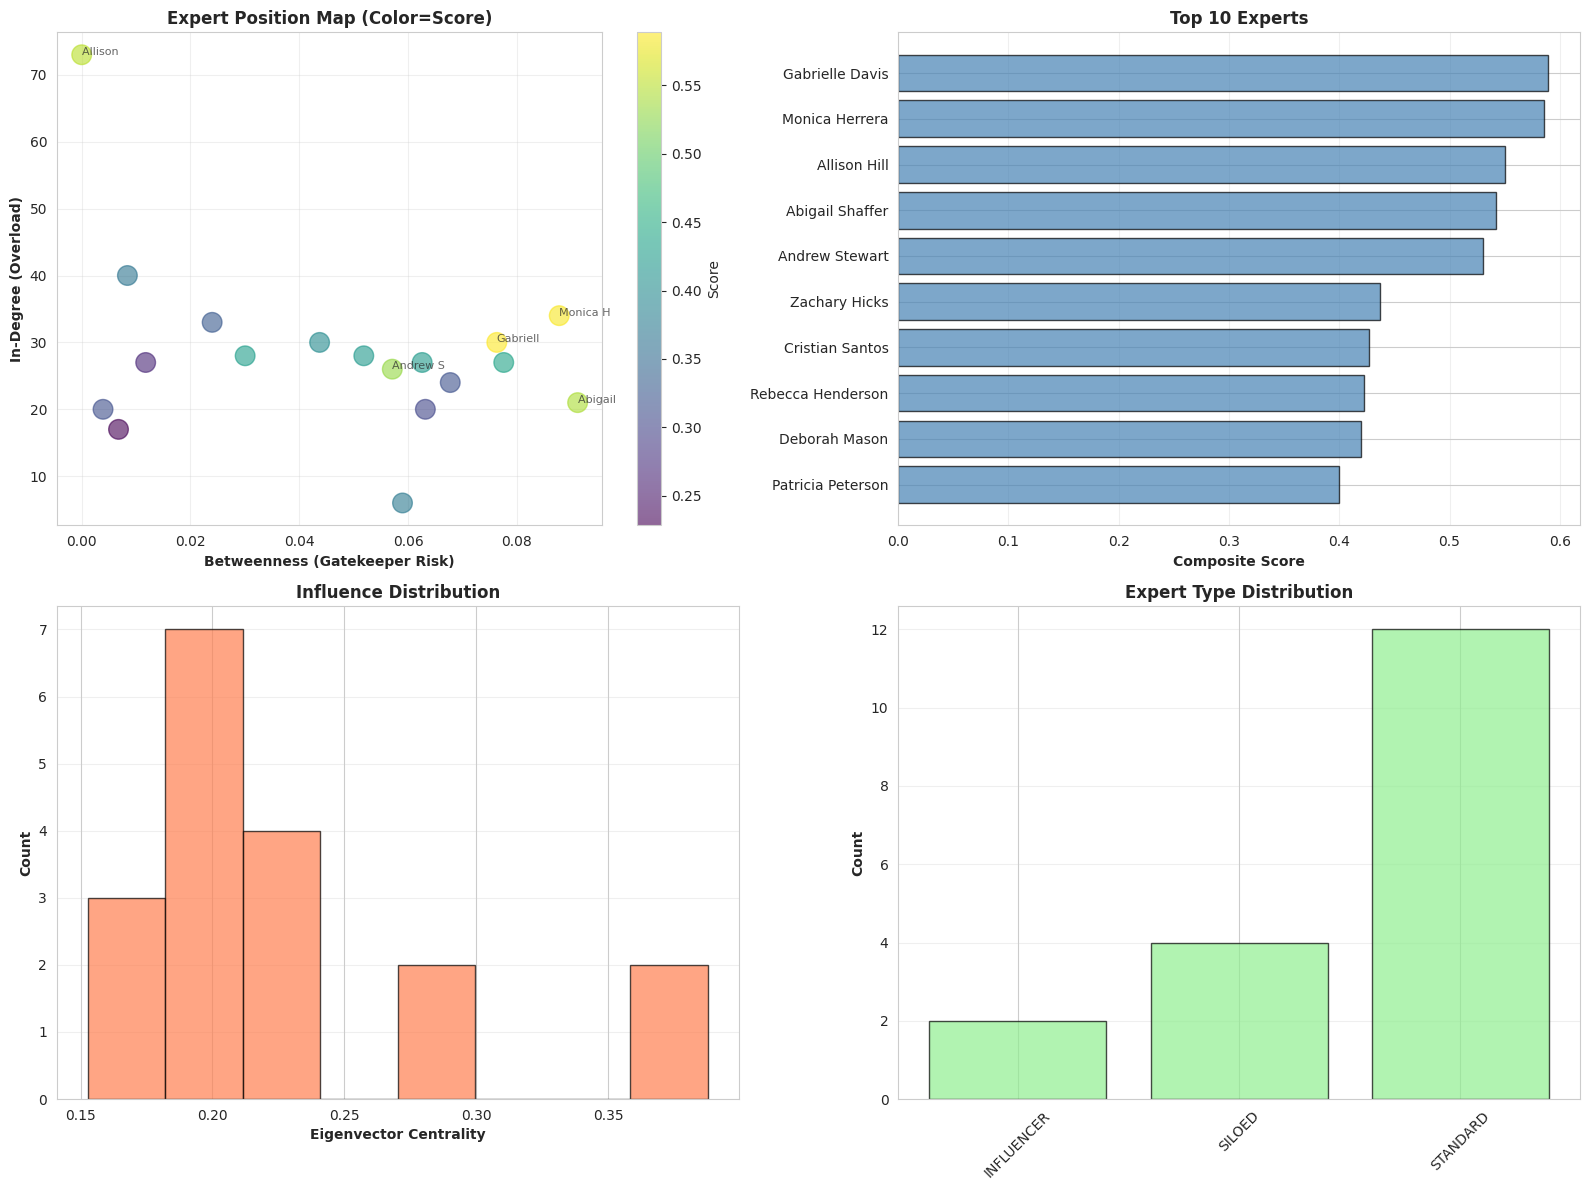

[OK] Visualization saved


In [8]:
# Cell 8: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes[0, 0]
in_degs = [in_degrees[p] for p in G_escalation.nodes()]
between = [betweenness[p] for p in G_escalation.nodes()]
colors = [expert_scores[p] for p in G_escalation.nodes()]
scatter = ax.scatter(between, in_degs, c=colors, s=200, alpha=0.6, cmap='viridis')
ax.set_xlabel('Betweenness (Gatekeeper Risk)', fontweight='bold')
ax.set_ylabel('In-Degree (Overload)', fontweight='bold')
ax.set_title('Expert Position Map (Color=Score)', fontweight='bold')
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Score')
for person_id in [t[0] for t in top_experts[:5]]:
    ax.annotate(G_escalation.nodes[person_id]['name'][:8], 
                (betweenness[person_id], in_degrees[person_id]),
                fontsize=8, alpha=0.7)

ax = axes[0, 1]
names = [G_escalation.nodes[p]['name'] for p, _ in top_experts[:10]]
scores = [s for _, s in top_experts[:10]]
colors_bar = [plt.cm.RdYlGn(expert_types[top_experts[i][0]] != 'BOTTLENECK') for i in range(10)]
ax.barh(names, scores, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Composite Score', fontweight='bold')
ax.set_title('Top 10 Experts', fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')

ax = axes[1, 0]
eigen_vals = sorted(eigenvector.values())
ax.hist(eigen_vals, bins=8, color='coral', alpha=0.7, edgecolor='black')
ax.set_xlabel('Eigenvector Centrality', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Influence Distribution', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

ax = axes[1, 1]
type_dist = defaultdict(int)
for t in expert_types.values():
    type_dist[t] += 1
types_list = sorted(type_dist.keys())
counts = [type_dist[t] for t in types_list]
ax.bar(types_list, counts, color='lightgreen', alpha=0.7, edgecolor='black')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Expert Type Distribution', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/tmp/experts_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print('[OK] Visualization saved')


In [9]:
# Cell 9: Recommendations & Summary
print('\n' + '='*70)
print('STRATEGIC RECOMMENDATIONS')
print('='*70)

bottlenecks = [p for p, t in expert_types.items() if t == 'BOTTLENECK']
bridges = [p for p, t in expert_types.items() if t == 'BRIDGE']
siloed = [p for p, t in expert_types.items() if t == 'SILOED']
overloaded = [p for p, t in expert_types.items() if t == 'OVERLOADED']

print('\n1. KNOWLEDGE TRANSFER (Top targets)')
print('─'*70)
transfer_targets = sorted(expert_scores.items(), key=lambda x: x[1], reverse=True)[:3]
for rank, (person_id, score) in enumerate(transfer_targets, 1):
    name = G_escalation.nodes[person_id]['name']
    team = G_escalation.nodes[person_id]['team']
    seniority = G_escalation.nodes[person_id]['seniority']
    print(f'{rank}. {name} ({team}, seniority={seniority}): Document expertise, mentor 2-3 juniors')

print('\n2. BOTTLENECK MITIGATION')
print('─'*70)
if bottlenecks:
    print(f'Found {len(bottlenecks)} bottleneck(s). Actions:')
    for person_id in bottlenecks:
        name = G_escalation.nodes[person_id]['name']
        print(f'  • Cross-train replacement for {name}')
        print(f'  • Delegate specific decision types')
        print(f'  • Bypass routing for low-risk escalations')
else:
    print('No severe bottlenecks detected.')

print('\n3. LEVERAGE HIDDEN EXPERTISE')
print('─'*70)
if siloed:
    print(f'Found {len(siloed)} siloed expert(s):')
    for person_id in siloed[:3]:
        name = G_escalation.nodes[person_id]['name']
        print(f'  • {name}: Create specialist track or knowledge base')
else:
    print('No siloed expertise detected.')

print('\n4. ORG RESILIENCE SCORE')
print('─'*70)
critical_risk = len([p for p in G_escalation.nodes() if betweenness[p] > np.percentile(list(betweenness.values()), 75)])
resilience_pct = max(0, 100 - (critical_risk / len(G_escalation.nodes()) * 100))
print(f'Critical nodes: {critical_risk}/{len(G_escalation.nodes())}')
print(f'Resilience score: {resilience_pct:.0f}% (target: 80%+)')
print(f'\nRecommendation: {"Acceptable" if resilience_pct >= 80 else "NEEDS IMPROVEMENT - single points of failure detected"}')

print('\n' + '='*70)
print('SUMMARY')
print('='*70)
print(f'\nNetwork: {G_escalation.number_of_nodes()} people, {G_escalation.number_of_edges()} escalation paths')
print(f'Top expert: {G_escalation.nodes[top_experts[0][0]]["name"]} (score={top_experts[0][1]:.3f})')
print(f'Natural clusters: {len(communities)}')
print(f'Type distribution: {dict(sorted(defaultdict(int, {t: len([p for p in expert_types if expert_types[p]==t]) for t in set(expert_types.values())}).items()))}')
print('\nExpected Impact: -20-30% escalation time, improved knowledge continuity, burnout prevention')
print('\n[DONE] Analysis complete!')



STRATEGIC RECOMMENDATIONS

1. KNOWLEDGE TRANSFER (Top targets)
──────────────────────────────────────────────────────────────────────
1. Gabrielle Davis (Platform, seniority=2): Document expertise, mentor 2-3 juniors
2. Monica Herrera (Security, seniority=2): Document expertise, mentor 2-3 juniors
3. Allison Hill (Platform, seniority=2): Document expertise, mentor 2-3 juniors

2. BOTTLENECK MITIGATION
──────────────────────────────────────────────────────────────────────
No severe bottlenecks detected.

3. LEVERAGE HIDDEN EXPERTISE
──────────────────────────────────────────────────────────────────────
Found 4 siloed expert(s):
  • Abigail Shaffer: Create specialist track or knowledge base
  • Shannon Ray: Create specialist track or knowledge base
  • Daniel Adams: Create specialist track or knowledge base

4. ORG RESILIENCE SCORE
──────────────────────────────────────────────────────────────────────
Critical nodes: 5/18
Resilience score: 72% (target: 80%+)

Recommendation: NEEDS IMPRO